# Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone --quiet --recursive https://github.com/cvg/Hierarchical-Localization/
%cd Hierarchical-Localization
!pip install --progress-bar off --quiet -e .
!pip install --progress-bar off --quiet --upgrade plotly
!pip uninstall -y --quiet pycolmap
# !pip install --progress-bar off --quiet "pycolmap-cuda12>=4.1.0"
!pip install --progress-bar off --quiet \
  "https://github.com/lyehe/build_gpu_colmap/releases/download/v4.1.0/pycolmap-4.1.0+cu128.bundled-cp312-cp312-manylinux_2_35_x86_64.whl"

/content/Hierarchical-Localization
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np

from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_retrieval
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d
import pycolmap

In [4]:
DATA_PATH = Path('/content/drive/MyDrive/buggy_hloc')
IMAGES_PATH = DATA_PATH / 'images'

In [5]:

videos = {v.stem: v for v in list(DATA_PATH.glob('*.mp4'))}
data = {}
for p in DATA_PATH.glob('vid_imu/*.json'):
    with open(p) as f:
        data[p.stem] = json.load(f)

# Create Images

In [12]:
import cv2

STRIDE = 1  # keep every Nth frame

for stem, video in tqdm(videos.items(), desc='videos'):
    start_ns = data[stem]['camera_start']  # video start, nanoseconds
    out_dir = IMAGES_PATH / stem
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    saved = 0
    i = 0
    try:
        with tqdm(total=frame_count, desc=stem, leave=False) as progress:
            while True:
                ok, frame = cap.read()
                if not ok:
                    break
                i += 1
                progress.update(1)
                if i % STRIDE != 0:
                    continue
                timestamp_ns = start_ns + int(round(cap.get(cv2.CAP_PROP_POS_MSEC) * 1_000_000))
                cv2.imwrite(str(out_dir / f"{timestamp_ns}.jpg"), frame)
                saved += 1
    finally:
        cap.release()
    print(f"{stem}: saved {saved} frames to {out_dir}")

videos:  20%|██        | 1/5 [03:42<14:49, 222.26s/it]

37: saved 10401 frames to /content/drive/MyDrive/buggy_hloc/images/37


videos:  40%|████      | 2/5 [06:02<08:42, 174.30s/it]

38: saved 6249 frames to /content/drive/MyDrive/buggy_hloc/images/38


videos:  60%|██████    | 3/5 [09:17<06:06, 183.47s/it]

45: saved 8259 frames to /content/drive/MyDrive/buggy_hloc/images/45


videos:  80%|████████  | 4/5 [14:01<03:43, 223.20s/it]

1401: saved 12090 frames to /content/drive/MyDrive/buggy_hloc/images/1401


videos: 100%|██████████| 5/5 [16:59<00:00, 203.89s/it]

1388: saved 7714 frames to /content/drive/MyDrive/buggy_hloc/images/1388


# Config

In [7]:
outputs = DATA_PATH / 'outputs'
outputs.mkdir(exist_ok=True)
sfm_pairs = outputs / 'pairs-sfm.txt'
loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
retreival_features = outputs / 'retrieval-features.h5'
matches = outputs / 'matches.h5'

retreival_conf = extract_features.confs['netvlad']
feature_conf = extract_features.confs['disk']
matcher_conf = match_features.confs['disk+lightglue']


In [8]:
# GPS_KIND, GPS_HZ, REF_STRIDE  = 'fit', 10, 2
GPS_KIND, GPS_HZ, REF_STRIDE = 'racebox', 25, 5

In [9]:
import h5py
import cv2

_m = cv2.imread(str(DATA_PATH / 'mask0.png'), cv2.IMREAD_GRAYSCALE)
assert _m is not None, "mask0.png not found in DATA_PATH"
mask = _m > 127  # True = keep; black (0) = exclude

def _feature_names(fd):
    """Leaf group names in an hloc h5 (image names nest via '/')."""
    names = []
    fd.visititems(lambda name, obj: names.append(name) if isinstance(obj, h5py.Group) and 'keypoints' in obj else None)
    return names

def filter_features(feature_path, mask):
    """Drop keypoints on black (excluded) mask regions from an hloc features.h5, in place. Idempotent."""
    resized = {}
    with h5py.File(str(feature_path), 'r+') as fd:
        for name in _feature_names(fd):
            grp = fd[name]
            kpts = grp['keypoints'][()]
            w, h = (int(v) for v in grp['image_size'][()])
            m = resized.get((h, w))
            if m is None:
                m = mask if mask.shape == (h, w) else cv2.resize(
                    mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
                resized[(h, w)] = m
            x = np.clip(np.round(kpts[:, 0]).astype(int), 0, w - 1)
            y = np.clip(np.round(kpts[:, 1]).astype(int), 0, h - 1)
            keep = m[y, x]
            n = len(kpts)
            for k in list(grp.keys()):
                arr = grp[k][()]
                axis = next((a for a, s in enumerate(arr.shape) if s == n), None)
                if axis is None:
                    continue
                del grp[k]
                grp.create_dataset(k, data=np.compress(keep, arr, axis=axis))

# Mapping

## Load Images

In [10]:
vid = "45"
image_paths = sorted((IMAGES_PATH / vid).glob('*.jpg'), key=lambda p: int(p.stem))
image_ts = np.array([int(p.stem) for p in image_paths])
imu_start = data[vid]['imu_data'][0]['timestamp']
gps_field = 'racebox_gps' if GPS_KIND == 'racebox' else 'gps_data'

# TODO: make this based on actual distance/speed/heading
references = {
    s['timestamp']: str(image_paths[np.abs(image_ts - s['timestamp']).argmin()].relative_to(IMAGES_PATH))
    for s in data[vid][gps_field][::REF_STRIDE] if s['timestamp'] > imu_start
}
len(references)

623

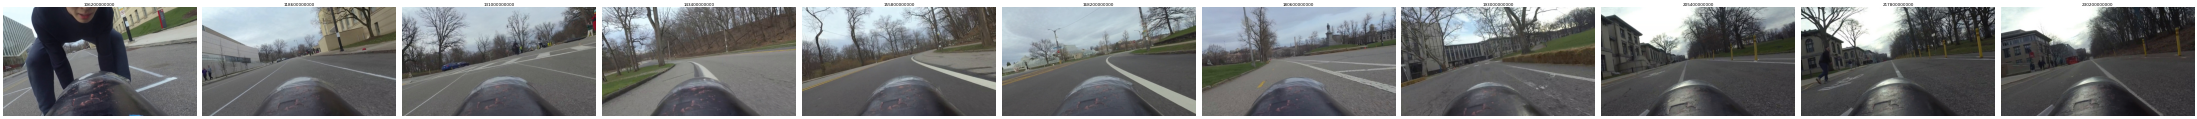

In [18]:
stride = len(references) // 10
plot_images([read_image(IMAGES_PATH / ref) for ref in list(references.values())[::stride]], 
            titles=[str(ts) for ts in list(references.keys())[::stride]], dpi=25)

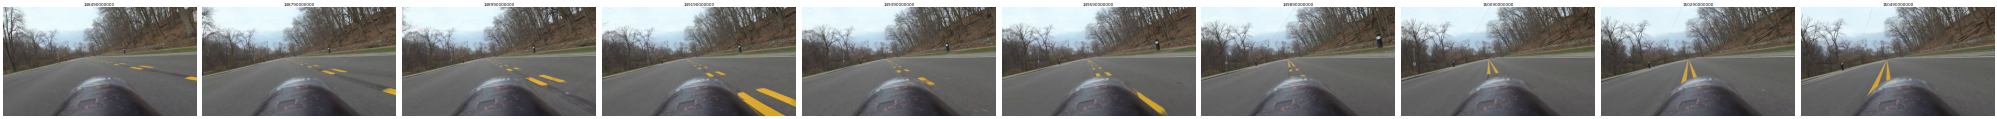

In [33]:
sl = slice(200, 210)
plot_images([read_image(IMAGES_PATH / ref) for ref in list(references.values())[sl]], 
            titles=[str(ts) for ts in list(references.keys())[sl]], dpi=25)

## Features

In [ ]:
# ~7min
extract_features.main(feature_conf, IMAGES_PATH, image_list=list(references.values()), feature_path=features, overwrite=True)
filter_features(features, mask)

with h5py.File(str(features), 'r') as fd:
    print('keypoints after masking:', sum(fd[n]['keypoints'].shape[0] for n in _feature_names(fd)))

In [23]:
extract_features.main(retreival_conf, IMAGES_PATH, image_list=list(references.values()), feature_path=retreival_features, overwrite=True)

[2026/07/03 04:05:43 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
100%|██████████| 529M/529M [00:05<00:00, 95.9MB/s] 
100%|██████████| 623/623 [01:02<00:00,  9.89it/s]
[2026/07/03 04:07:15 hloc INFO] Finished exporting features.


PosixPath('/content/drive/MyDrive/buggy_hloc/outputs/retrieval-features.h5')

## Matching

In [24]:
pairs_from_retrieval.main(retreival_features, sfm_pairs, num_matched=10)

[2026/07/03 04:07:15 hloc INFO] Extracting image pairs from a retrieval database.


[2026/07/03 04:07:18 hloc INFO] Found 6230 pairs.


In [25]:
match_features.main(matcher_conf, sfm_pairs, features, matches=matches, overwrite=True)

[2026/07/03 04:07:18 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/disk_lightglue.pth" to /root/.cache/torch/hub/checkpoints/disk_lightglue_v0-1_arxiv.pth


100%|██████████| 45.4M/45.4M [00:00<00:00, 61.5MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/3667 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n

PosixPath('/content/drive/MyDrive/buggy_hloc/outputs/matches.h5')

## Reconstruct

In [11]:
model = reconstruction.main(
  sfm_dir, IMAGES_PATH, sfm_pairs, features, matches, verbose=True, 
  image_list=sorted(set(references.values())),
  mapper_options={
      "ba_local_backend": pycolmap.BundleAdjustmentBackend.CASPAR,
      "ba_global_backend": pycolmap.BundleAdjustmentBackend.CASPAR,
  })

[2026/07/07 01:38:12 hloc INFO] Writing COLMAP logs to /content/drive/MyDrive/buggy_hloc/outputs/sfm/colmap.LOG.*


[2026/07/07 01:38:13 hloc WARNING] The database already exists, deleting it.
[2026/07/07 01:38:13 hloc INFO] Creating an empty database...
[2026/07/07 01:38:14 hloc INFO] Importing images into the database...
[2026/07/07 01:51:03 hloc INFO] Importing features into the database...
100%|██████████| 623/623 [07:32<00:00,  1.38it/s]
[2026/07/07 01:58:35 hloc INFO] Importing matches into the database...
100%|██████████| 6230/6230 [00:53<00:00, 115.88it/s] 
[2026/07/07 01:59:30 hloc INFO] Performing geometric verification of the matches...
[2026/07/07 02:00:57 hloc INFO] Running 3D reconstruction...
Reconstruction 6:  19%|█▉        | 121/623 [03:55<16:16,  1.95s/images, registered]
[2026/07/07 02:37:14 hloc INFO] Reconstructed 5 model(s).
[2026/07/07 02:37:14 hloc INFO] Largest model is #1 with 343 images.
[2026/07/07 02:37:14 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_rigs = 343
	num_cameras = 343
	num_frames = 343
	num_reg_frames = 343
	num_images = 343
	num_points3D = 9986

In [13]:
p = DATA_PATH / 'outputs' / 'no_prior'
p.mkdir(parents=True, exist_ok=True)
model.write(DATA_PATH / 'outputs' / 'no_prior')